# <center> Estimating the denisty of the tom positive and negative cells

Run this notebook after finishing `Explore_Notebook/1.explore_datasets/2.check_HSPC_atlas_tom.ipynb`

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

import PINN
from PINN import pl, tl, reader

In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
tompos = sc.read_h5ad("data/tom_pos.h5ad")
tomneg = sc.read_h5ad("data/tom_neg.h5ad")

In [4]:
tompos.uns['pop']

{'mean': array([  147.        ,   388.64570792,   576.69290022,  1846.6599877 ,
         3123.27770491,  8233.9326366 , 13949.54802458,  4941.85061577,
        41722.98597037]),
 'n_lib': array([4, 6, 4, 4, 4, 2, 4, 4, 2]),
 't': array([  3,   7,  12,  27,  49,  76, 112, 161, 269]),
 'var': array([  45.74567375,  254.32999527,  169.72430757, 1347.94980559,
        2110.00764584,  446.60597854, 6560.28356116, 3795.97826525,
        1788.57045978])}

In [5]:
ad = sc.read_h5ad("data/combined_filt.h5ad")
young_mouse_cbs = pd.read_table('data/continurous_young_mouse_cbs.txt')['cellbarcode'].values.tolist()
ad = ad[young_mouse_cbs].copy()

# compute density

In [45]:
cellstate = ad.obsm['DM_EigenVectors'].copy()

In [46]:
ub_pos_ls, den_pos_fn = tl.compute_highdim_density(tompos, timepoint_key='timepoint_tx_days', cellstate=cellstate)

In [48]:
ub_pos_ls = np.stack(ub_pos_ls)

prediction of shape (9, 112003)
prediction ranging between [0. 0. 0. 0. 0. 0. 0. 0. 0.] [4.46354656e+107 1.01737185e+099 3.05596872e+099 4.08358172e+094
 1.31424568e+093 4.51705222e+095 1.80349111e+093 2.83872700e+090
 1.32014361e+092]


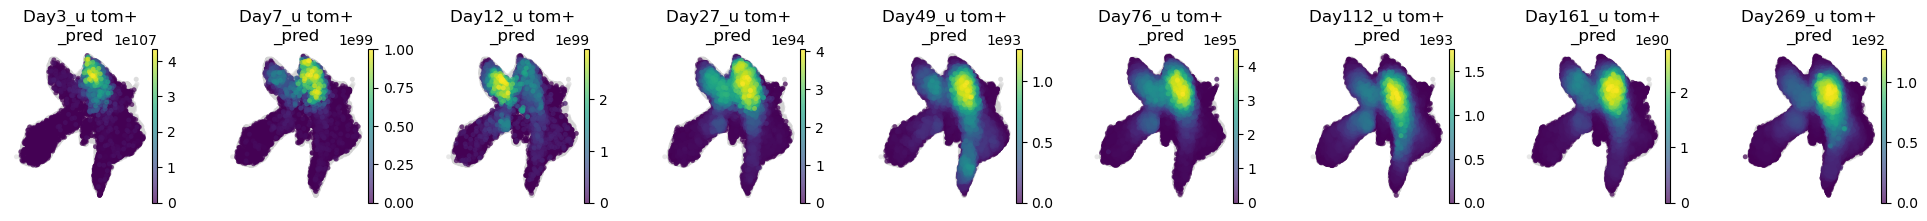

In [58]:
pl.params_in_umap(ad, ub_pos_ls, param='u tom+\n')

In [ ]:
ub_neg_ls, den_neg_fn = tl.cocmpute_highdim_density(tomneg, timepoint_key='timepoint_tx_days')

# normalization

In [8]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler(feature_range=(-2,2))
scaled_DM = scaler.fit_transform(ad.obsm['DM_EigenVectors'].copy())
ad.obsm['DM_scaled'] = scaled_DM

In [54]:
tompos.obsm['DM_scaled'] = ad[tompos.obs_names].obsm['DM_scaled']
tomneg.obsm['DM_scaled'] = ad[tomneg.obs_names].obsm['DM_scaled']

# tompos.write_h5ad("data/tom_pos.h5ad")
# tomneg.write_h5ad("data/tom_neg.h5ad")

# compute density

In [10]:
cellstate = ad.obsm['DM_scaled'].copy()

In [ ]:
ad.obsm['X_diffmap'].min(axis=0), ad.obsm['X_diffmap'].max(axis=0)

(array([-0.00368871, -0.00388465, -0.00297033, -0.00453255, -0.00589846,
        -0.01099867, -0.00226546, -0.01216327, -0.00781331, -0.01022038,
        -0.01444286, -0.00776346, -0.00825789, -0.01084033, -0.01116304],
       dtype=float32),
 array([-0.00169443,  0.00368766,  0.01044799,  0.01325069,  0.00769025,
         0.00402121,  0.03118771,  0.00637895,  0.0032891 ,  0.0074993 ,
         0.00599494,  0.00991968,  0.01242057,  0.00381335,  0.00172611],
       dtype=float32))

In [ ]:
tompos.obsm['X_diffmap'].std(axis=0), tompos.obsm['X_diffmap'].std(axis=0)

(array([0.00022398, 0.00080948, 0.00253915, 0.00137194, 0.00239492,
        0.00115239, 0.0008954 , 0.00131677, 0.00196388, 0.00174281,
        0.00210393, 0.00211715, 0.00247743, 0.00115179, 0.00055928],
       dtype=float32),
 array([0.00022398, 0.00080948, 0.00253915, 0.00137194, 0.00239492,
        0.00115239, 0.0008954 , 0.00131677, 0.00196388, 0.00174281,
        0.00210393, 0.00211715, 0.00247743, 0.00115179, 0.00055928],
       dtype=float32))

In [13]:
ad.uns['pop'] = tompos.uns['pop']

In [11]:
ub_pos_ls, den_pos_fn = tl.compute_highdim_density(tompos, 
                                                    cellstate_key='DM_scaled', 
                                                   timepoint_key='timepoint_tx_days',
                                                   cellstate=cellstate
                                                   )
ub_pos_ls = np.stack(ub_pos_ls)
ub_pos_ls.shape

(9, 112003)

prediction of shape (9, 49390)


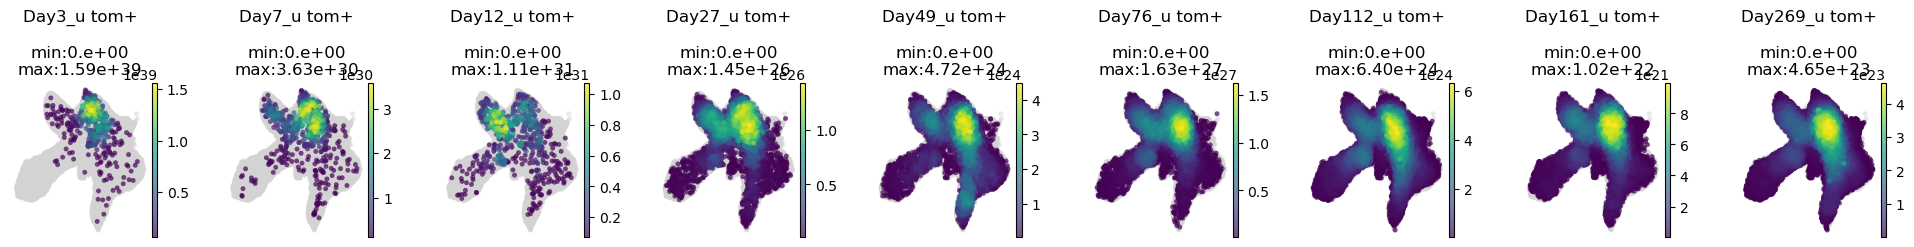

In [ ]:
pl.params_in_umap(tompos, ub_pos_ls, param='u tom+\n');

In [16]:
ub_pos_all = np.stack([dfn(cellstate.T) for dfn in den_pos_fn])
ub_pos_all.shape

KeyboardInterrupt: 

prediction of shape (9, 112003)


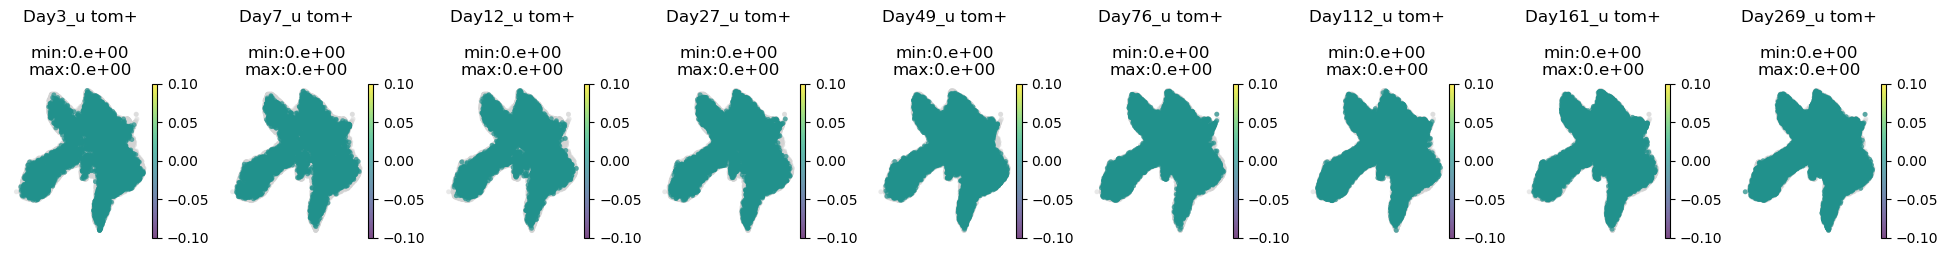

In [ ]:
# ub_pos_all = ub_pos_ls
pl.params_in_umap(ad, ub_pos_all, param='u tom+\n');

In [15]:
ub_neg_ls, den_neg_fn = tl.compute_highdim_density(tomneg, cellstate_key='DM_scaled', 
                                                   timepoint_key='timepoint_tx_days',
                                                   cellstate=cellstate
                                                   )
ub_neg_ls = np.stack(ub_neg_ls)
print(ub_neg_ls.shape)

(9, 112003)


prediction of shape (9, 62613)


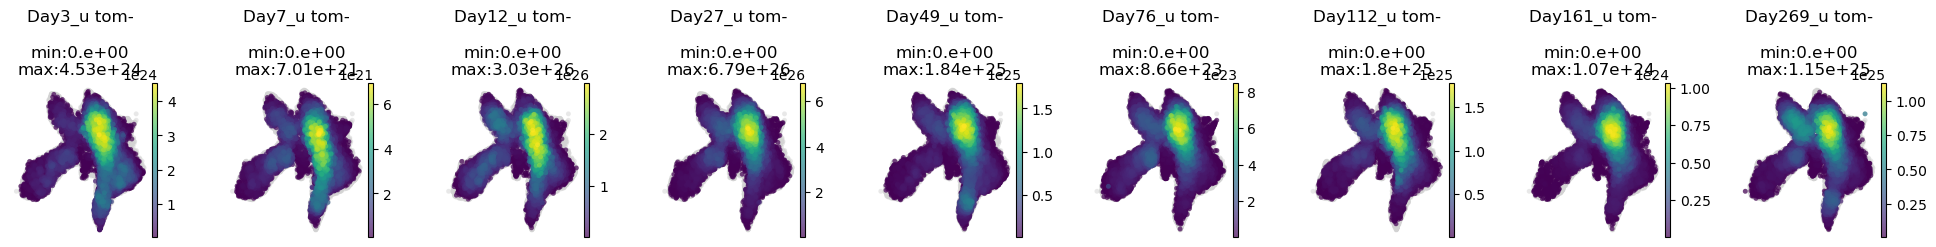

In [58]:
pl.params_in_umap(tomneg, ub_neg_ls, param='u tom-\n');

In [62]:
ub_neg_all = np.stack([dfn(cellstate.T) for dfn in den_neg_fn])
ub_neg_all.shape

(9, 112003)

prediction of shape (9, 112003)


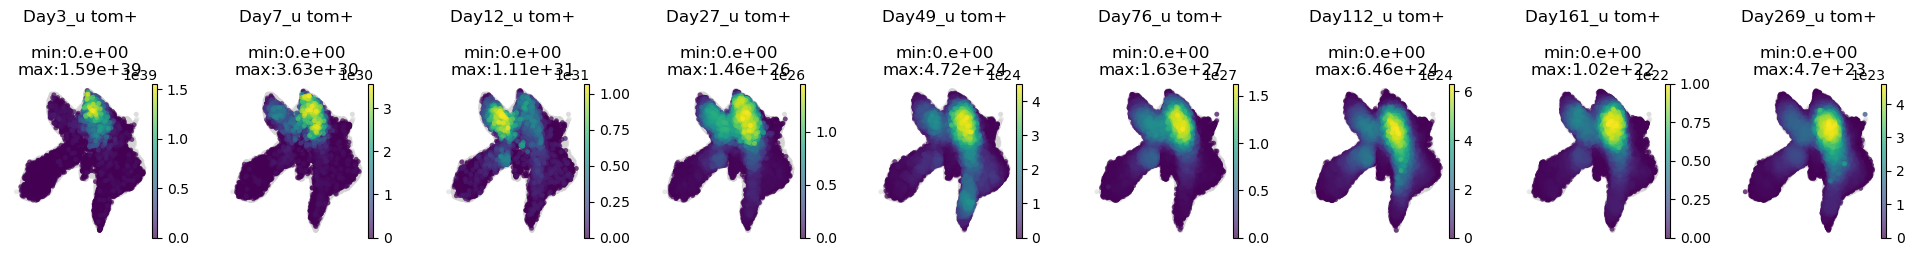

In [ ]:
ub_neg_all = ub_neg_ls
pl.params_in_umap(ad, ub_neg_all, param='u tom+\n');